Things I have to add for numerical data
- ~~'BOX PLOT'~~
- 'DENSITY_PLOT'
- 'CONNECTED_SCATTER PLOT'
- '3D_SCATTEROR_SURFACE'
- 'PCA'
- 'RIDGE_LINE'
- 'DENDROGRAM'
- 'SCATTER_WITH_MARGINAL_POINT'
- 'BOX_PLOT'
- 'SCATTER_PLOT'
- 'STACKED_AREA_PLOT'
- 'VIOLIN_PLOT'
- 'AREA(SM)'
- 'STREAM_GRAPH'
- 'LINE_PLOT'
- 'BUBBLE_PLOT'
- '2D_DENSITY_PLOT'
- 'HISTOGRAM'
- 'AREA_PLOT'
- 'CORRELOGRAM'
- 'HEATMAP'

In [166]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [167]:
class Boxplot:
    def __init__(self, df, x=None, y=None, hue=None, order=None, hue_order=None, 
                 orient=None, color=None, palette=None, saturation=0.75, width=0.8, dodge=True, 
                 fliersize=5, linewidth=None, whis=1.5, ax=None, title=None, **kwargs):
        self.__df = df
        self.__x = x
        self.__y = y
        self.__hue = hue
        self.__order = order
        self.__hue_order = hue_order
        self.__orient = orient
        self.__color = color
        self.__palette = palette
        self.__saturation = saturation
        self.__width = width
        self.__dodge = dodge
        self.__fliersize = fliersize
        self.__linewidth = linewidth
        self.__whis = whis
        self.__ax = ax
        self.__title = title
        self.__kwargs = kwargs

    def plot(self):
        sns.boxplot(x=self.__x, y=self.__y, hue=self.__hue, data=self.__df, order=self.__order, 
                    hue_order=self.__hue_order, orient=self.__orient, color=self.__color, 
                    palette=self.__palette, saturation=self.__saturation, width=self.__width, 
                    dodge=self.__dodge, fliersize=self.__fliersize, linewidth=self.__linewidth, 
                    whis=self.__whis, ax=self.__ax, **self.__kwargs)

        if self.__ax:
            nobs = self.__df.groupby(self.__x).size().values
            nobs = [str(x) for x in nobs.tolist()]
            nobs = ["n: " + i for i in nobs]

            pos = range(len(nobs))
            medians = self.__df.groupby(self.__x)[self.__y].median().values
            for tick, label in zip(pos, self.__ax.get_xticklabels()):
                self.__ax.text(pos[tick], medians[tick] + 0.1, nobs[tick], horizontalalignment='center', 
                             size='medium', color='w', weight='semibold')

        if self.__title:
            plt.title(self.__title)

    def save_plot(self, file_name, folder=None):
        if folder:
            if not os.path.exists(folder):
                os.makedirs(folder)
            file_name = os.path.join(folder, file_name)
        self.plot()
        plt.savefig(file_name)
        plt.show()

In [168]:
a = pd.DataFrame({ 'group' : np.repeat('A',500), 'value': np.random.normal(10, 5, 500) })
b = pd.DataFrame({ 'group' : np.repeat('B',500), 'value': np.random.normal(13, 1.2, 500) })
c = pd.DataFrame({ 'group' : np.repeat('B',500), 'value': np.random.normal(18, 1.2, 500) })
d = pd.DataFrame({ 'group' : np.repeat('C',20), 'value': np.random.normal(25, 4, 20) })
e = pd.DataFrame({ 'group' : np.repeat('D',100), 'value': np.random.uniform(12, size=100) })
df= pd.concat([a, b, c, d], axis=0)


In [169]:

# df = sns.load_dataset('iris')

In [170]:
# Boxplot(df, 'species', 'sepal_length')
# Boxplot(df, x='group', y='value', title='avbasd')

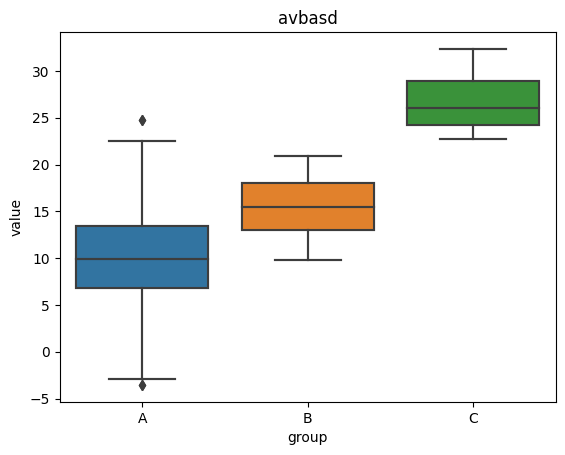

In [171]:
asd = Boxplot(df, x='group', y='value', title='avbasd')
asd.plot()
asd.save_plot('box_plot.png')